In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
%matplotlib inline

### Load Dataset

In [6]:
import pandas as pd

df = pd.read_csv('df.csv').iloc[:,2:]

df.head()


,MATERIAL_PAREDES,MATERIAL_PISOS,MATERIAL_TECHOS,ELECTRICIDAD,NUM_HABITACIONES,INTERNET,ABASTECIMIENTO_AGUA,AGUA_POTABLE,SERVICIOS_HIGIENICOS,TIENE_SEGURO,NINOS_ASISTEN_COLEGIO,SITUACION_EDUCATIVA_ESPERADA,SABE_LEER_ESCRIBIR,TIPO_TRABAJADOR,INGRESO_TOTAL,RECIBIO_PENSION65,RECIBIO_JUNTOS,MONTO_JUNTOS,MONTO_PENSION65
0,3,1,4,1,4,0,5,1,1,1,1,0,1,3,2602.0,0,0,0.0,0.0
1,4,3,4,1,4,0,5,1,1,1,1,0,1,3,1200.0,0,0,0.0,0.0
2,4,3,3,1,3,0,5,0,1,1,1,0,1,3,2500.0,0,0,0.0,0.0
3,4,3,3,1,3,0,5,0,1,1,1,0,1,3,1800.0,0,0,0.0,0.0
4,3,3,3,1,2,0,5,0,1,1,1,0,1,3,3000.0,0,0,0.0,0.0


### Scale Data

In [7]:
# Scale Data
for col in df.columns:  # Iterate through each column in the DataFrame
    avg = df[col].mean()  # Calculate the mean (average) of the current column
    sd = df[col].std()  # Calculate the standard deviation of the current column
    df[col] = df[col].apply(lambda x: (x - avg) / sd)  # Apply z-score standardization: (value - mean) / std_dev
df.head()  # Display the first 5 rows of the scaled DataFrame

,MATERIAL_PAREDES,MATERIAL_PISOS,MATERIAL_TECHOS,ELECTRICIDAD,NUM_HABITACIONES,INTERNET,ABASTECIMIENTO_AGUA,AGUA_POTABLE,SERVICIOS_HIGIENICOS,TIENE_SEGURO,NINOS_ASISTEN_COLEGIO,SITUACION_EDUCATIVA_ESPERADA,SABE_LEER_ESCRIBIR,TIPO_TRABAJADOR,INGRESO_TOTAL,RECIBIO_PENSION65,RECIBIO_JUNTOS,MONTO_JUNTOS,MONTO_PENSION65
0,-0.735407,-2.100430,0.843705,0.100763,0.222833,-1.273031,0.192082,0.444982,0.165898,0.417292,0.06874,-0.358981,0.116388,0.83738,0.708527,-0.063396,-0.12871,-0.127648,-0.06293
1,0.594715,0.020108,0.843705,0.100763,0.222833,-1.273031,0.192082,0.444982,0.165898,0.417292,0.06874,-0.358981,0.116388,0.83738,-0.249106,-0.063396,-0.12871,-0.127648,-0.06293
2,0.594715,0.020108,-0.776934,0.100763,-0.454691,-1.273031,0.192082,-2.247258,0.165898,0.417292,0.06874,-0.358981,0.116388,0.83738,0.638856,-0.063396,-0.12871,-0.127648,-0.06293
3,0.594715,0.020108,-0.776934,0.100763,-0.454691,-1.273031,0.192082,-2.247258,0.165898,0.417292,0.06874,-0.358981,0.116388,0.83738,0.160723,-0.063396,-0.12871,-0.127648,-0.06293
4,-0.735407,0.020108,-0.776934,0.100763,-1.132216,-1.273031,0.192082,-2.247258,0.165898,0.417292,0.06874,-0.358981,0.116388,0.83738,0.980380,-0.063396,-0.12871,-0.127648,-0.06293


### DBSCAN without tuning

In [8]:
# Implement DBSCAN
min_samples = df.shape[1] * 2  # Set min_samples to twice the number of features/columns
dbscan = DBSCAN(eps=0.5, min_samples=min_samples)  # Create DBSCAN object with eps=0.5 and calculated min_samples
clusters = dbscan.fit_predict(df)  # Fit the model to data and predict cluster labels for each point
print('clusters created: ' + str(list(set(clusters))))  # Print unique cluster labels (including -1 for noise points)

clusters created: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70

### Tune Eps via KNN

In [9]:
# Choose k and compute neighbor distances
k = min_samples if min_samples > 2 else 2  # Set k to min_samples, but ensure it's at least 2
nbrs = NearestNeighbors(n_neighbors=k).fit(df)  # Create and fit a NearestNeighbors model to find k nearest neighbors
distances, indices = nbrs.kneighbors(df)  # Calculate distances and indices of k nearest neighbors for each point

In [10]:
print('min samples: ' + str(min_samples))  # Display the min_samples value used in DBSCAN
print('shape of distances matrix: ' + str(distances.shape) + '\n')  # Show dimensions of distances array (rows=data points, cols=k neighbors)

# Loop through the first 5 observations and display their neighbor distances
for enum, row in enumerate(distances[:5]):  # Iterate through first 5 rows of distances matrix with enumeration
    print('observation ' + str(enum) + ': ' + str([round(x, 2) for x in row]))  # Print observation index and rounded distances to k nearest neighbors

min samples: 38
shape of distances matrix: (91431, 38)

observation 0: [np.float64(0.0), np.float64(0.27), np.float64(0.34), np.float64(0.41), np.float64(0.41), np.float64(0.55), np.float64(0.68), np.float64(0.68), np.float64(0.73), np.float64(0.79), np.float64(0.83), np.float64(0.89), np.float64(0.92), np.float64(0.93), np.float64(0.96), np.float64(0.96), np.float64(0.96), np.float64(0.96), np.float64(0.96), np.float64(1.0), np.float64(1.04), np.float64(1.09), np.float64(1.1), np.float64(1.11), np.float64(1.11), np.float64(1.14), np.float64(1.14), np.float64(1.14), np.float64(1.14), np.float64(1.14), np.float64(1.15), np.float64(1.16), np.float64(1.16), np.float64(1.17), np.float64(1.19), np.float64(1.23), np.float64(1.23), np.float64(1.26)]
observation 1: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64

* 150 rows → one row per sample in the dataset (the Iris set has 150 observations).
* 8 columns → for each sample you stored the distances to its 8 nearest neighbors (first value is 0 for the point itself when querying the same data).

In [11]:
# the last cell of each row represents the distance of the k'th farthest point
df['knn_farthest_dist'] = distances[:, -1]  # Add new column with k-th nearest neighbor distance for each point
df.head()  # Display first 5 rows of DataFrame including the new knn_farthest_dist column

,MATERIAL_PAREDES,MATERIAL_PISOS,MATERIAL_TECHOS,ELECTRICIDAD,NUM_HABITACIONES,INTERNET,ABASTECIMIENTO_AGUA,AGUA_POTABLE,SERVICIOS_HIGIENICOS,TIENE_SEGURO,NINOS_ASISTEN_COLEGIO,SITUACION_EDUCATIVA_ESPERADA,SABE_LEER_ESCRIBIR,TIPO_TRABAJADOR,INGRESO_TOTAL,RECIBIO_PENSION65,RECIBIO_JUNTOS,MONTO_JUNTOS,MONTO_PENSION65,knn_farthest_dist
0,-0.735407,-2.100430,0.843705,0.100763,0.222833,-1.273031,0.192082,0.444982,0.165898,0.417292,0.06874,-0.358981,0.116388,0.83738,0.708527,-0.063396,-0.12871,-0.127648,-0.06293,1.258268
1,0.594715,0.020108,0.843705,0.100763,0.222833,-1.273031,0.192082,0.444982,0.165898,0.417292,0.06874,-0.358981,0.116388,0.83738,-0.249106,-0.063396,-0.12871,-0.127648,-0.06293,0.034152
2,0.594715,0.020108,-0.776934,0.100763,-0.454691,-1.273031,0.192082,-2.247258,0.165898,0.417292,0.06874,-0.358981,0.116388,0.83738,0.638856,-0.063396,-0.12871,-0.127648,-0.06293,0.730540
3,0.594715,0.020108,-0.776934,0.100763,-0.454691,-1.273031,0.192082,-2.247258,0.165898,0.417292,0.06874,-0.358981,0.116388,0.83738,0.160723,-0.063396,-0.12871,-0.127648,-0.06293,0.546438
4,-0.735407,0.020108,-0.776934,0.100763,-1.132216,-1.273031,0.192082,-2.247258,0.165898,0.417292,0.06874,-0.358981,0.116388,0.83738,0.980380,-0.063396,-0.12871,-0.127648,-0.06293,1.004131


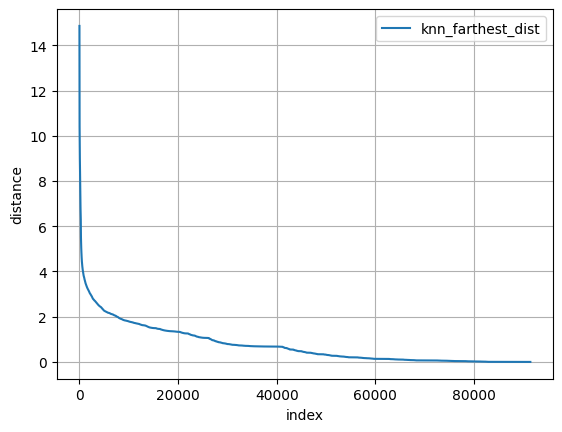

In [12]:
# Plot the k-distance graph
df.sort_values('knn_farthest_dist', ascending=False).reset_index()[['knn_farthest_dist']].plot()  # Sort by k-distance (high to low), reset index, and plot
plt.xlabel('index')  # Label x-axis as 'index' (represents sorted data points)
plt.ylabel('distance')  # Label y-axis as 'distance' (k-th nearest neighbor distance)
plt.grid(True)  # Add grid lines to the plot for better readability
plt.show()  # Display the plot

In [ ]:
# DBSCAN using chosen params
km = DBSCAN(eps=3, min_samples=min_samples)
df['cluster'] = km.fit_predict(df.iloc[:,:-1])
df.cluster.value_counts()